**A Data-Driven Study of Market Sentiment and Its Impact on Cryptocurrency Trading Performance**

1. Setup & Imports

In [58]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

2. Load Data

In [59]:
# ==============================
# LOAD DATA
# ==============================

trader_url = "https://drive.google.com/uc?id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs"
sentiment_url = "https://drive.google.com/uc?id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf"

trader_df = pd.read_csv(trader_url)
sentiment_df = pd.read_csv(sentiment_url)

print("Trader Data Shape:", trader_df.shape)
print("Sentiment Data Shape:", sentiment_df.shape)

Trader Data Shape: (211224, 16)
Sentiment Data Shape: (2644, 4)


3. Data Cleaning

In [60]:
# ==============================
# CLEAN TRADER DATA
# ==============================

# Standardize column names
trader_df.columns = (
    trader_df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# Convert timestamp
trader_df['timestamp_ist'] = pd.to_datetime(
    trader_df['timestamp_ist'],
    dayfirst=True,
    errors='coerce'
)

# Extract date
trader_df['date'] = trader_df['timestamp_ist'].dt.date

# Rename
trader_df.rename(columns={'timestamp_ist': 'time'}, inplace=True)

# Convert numeric columns
trader_df['closed_pnl'] = pd.to_numeric(trader_df['closed_pnl'], errors='coerce')
trader_df['size_usd'] = pd.to_numeric(trader_df['size_usd'], errors='coerce')

# Improved risk proxy (normalized position size)
trader_df['risk'] = trader_df['size_usd'] / trader_df['size_usd'].abs().mean()

# Drop missing
trader_df = trader_df.dropna(subset=['closed_pnl'])

print("Trader data cleaned ✅")


# ==============================
# CLEAN SENTIMENT DATA
# ==============================

sentiment_df.columns = (
    sentiment_df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# Convert date
sentiment_df['date'] = pd.to_datetime(
    sentiment_df['date'],
    errors='coerce'
).dt.date

# Encode sentiment (ordinal)
sentiment_map = {
    'Extreme Fear': 0,
    'Fear': 1,
    'Neutral': 2,
    'Greed': 3,
    'Extreme Greed': 4
}

sentiment_df['sentiment'] = sentiment_df['classification'].map(sentiment_map)

print("Sentiment data cleaned ✅")

Trader data cleaned ✅
Sentiment data cleaned ✅


4. Merge Datasets

In [61]:
# ==============================
# MERGE DATA
# ==============================

merged_df = trader_df.merge(
    sentiment_df[['date', 'classification', 'sentiment']],
    on='date',
    how='left'
)

print("Merged Data Shape:", merged_df.shape)

Merged Data Shape: (211224, 20)


5. BASIC ANALYSIS

In [62]:
# ==============================
# BASIC METRICS
# ==============================

# Profitability
avg_pnl = merged_df.groupby('classification')['closed_pnl'].mean()
print("\nAverage PnL:\n", avg_pnl)

# Win rate
merged_df['is_profit'] = merged_df['closed_pnl'] > 0
win_rate = merged_df.groupby('classification')['is_profit'].mean()
print("\nWin Rate:\n", win_rate)

# Risk behavior
risk_behavior = merged_df.groupby('classification')['risk'].mean()
print("\nRisk Behavior:\n", risk_behavior)

# Trade count
trade_count = merged_df['classification'].value_counts()
print("\nTrade Count:\n", trade_count)


Average PnL:
 classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: closed_pnl, dtype: float64

Win Rate:
 classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: is_profit, dtype: float64

Risk Behavior:
 classification
Extreme Fear     0.948626
Extreme Greed    0.551871
Fear             1.385970
Greed            1.017277
Neutral          0.848085
Name: risk, dtype: float64

Trade Count:
 classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


6. VISUALIZATIONS

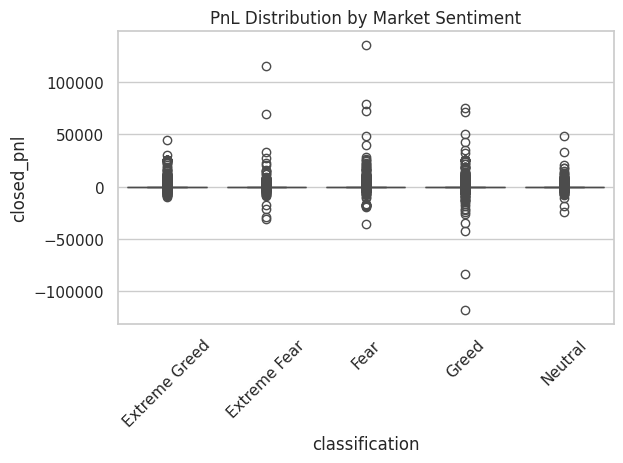

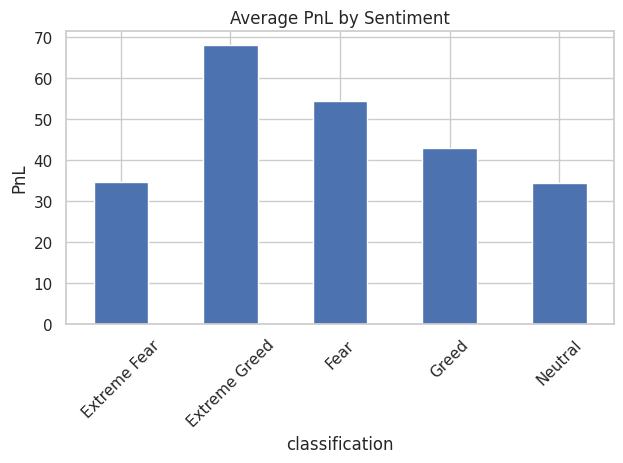

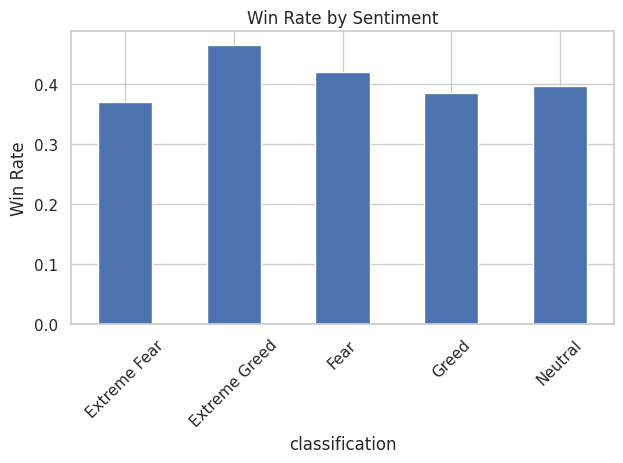

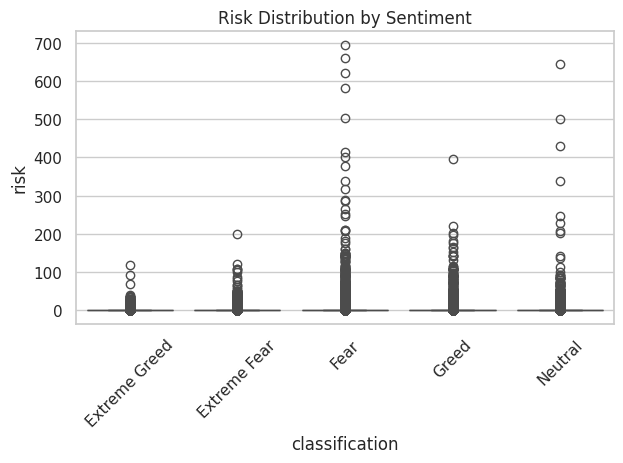

In [63]:
# ==============================
# VISUALIZATION
# ==============================

# PnL Distribution
plt.figure()
sns.boxplot(data=merged_df, x='classification', y='closed_pnl')
plt.xticks(rotation=45)
plt.title("PnL Distribution by Market Sentiment")
plt.tight_layout()
plt.show()

# Average PnL
plt.figure()
avg_pnl.plot(kind='bar')
plt.title("Average PnL by Sentiment")
plt.ylabel("PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Win Rate
plt.figure()
win_rate.plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Risk Distribution
plt.figure()
sns.boxplot(data=merged_df, x='classification', y='risk')
plt.xticks(rotation=45)
plt.title("Risk Distribution by Sentiment")
plt.tight_layout()
plt.show()

7. TRADER PERFORMANCE

In [64]:
# ==============================
# TRADER PERFORMANCE
# ==============================

trader_perf = merged_df.groupby('account').agg({
    'closed_pnl': 'sum',
    'is_profit': 'mean',
    'risk': 'mean'
}).reset_index()

trader_perf.columns = ['account', 'total_pnl', 'win_rate', 'avg_risk']

# Risk-adjusted return (IMPORTANT)
trader_perf['risk_adjusted_return'] = (
    trader_perf['total_pnl'] / (trader_perf['avg_risk'] + 1e-6)
)

# Top traders
top_traders = trader_perf.sort_values(by='total_pnl', ascending=False).head(10)
print("\nTop Traders:\n", top_traders)


Top Traders:
                                        account     total_pnl  win_rate  \
27  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2.143383e+06  0.337134   
0   0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06  0.359612   
29  0xbaaaf6571ab7d571043ff1e313a9609a10637864  9.401638e+05  0.467582   
13  0x513b8629fe877bb581bf244e326a047b249c4ff1  8.404226e+05  0.401193   
31  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  8.360806e+05  0.428230   
11  0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  6.777471e+05  0.486226   
15  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  4.293556e+05  0.345912   
9   0x430f09841d65beb3f27765503d0f850b8bce7713  4.165419e+05  0.484236   
16  0x72c6a4624e1dffa724e6d00d64ceae698af892a0  4.030115e+05  0.306294   
17  0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4  3.790954e+05  0.810876   

    avg_risk  risk_adjusted_return  
27  0.680542          3.149517e+06  
0   2.865452          5.584561e+05  
29  0.569288          1.651470e+06  
13  6.099278          

8. TOP TRADERS VS SENTIMENT

In [65]:
# ==============================
# TOP TRADERS ANALYSIS
# ==============================

top_accounts = top_traders['account']

top_data = merged_df[merged_df['account'].isin(top_accounts)]

top_sentiment_perf = top_data.groupby('classification')['closed_pnl'].mean()

print("\nTop Traders Sentiment Performance:\n", top_sentiment_perf)


Top Traders Sentiment Performance:
 classification
Extreme Fear      60.765008
Extreme Greed    136.960455
Fear              66.979192
Greed             93.526109
Neutral           53.831636
Name: closed_pnl, dtype: float64


9. TIME SERIES ANALYSIS

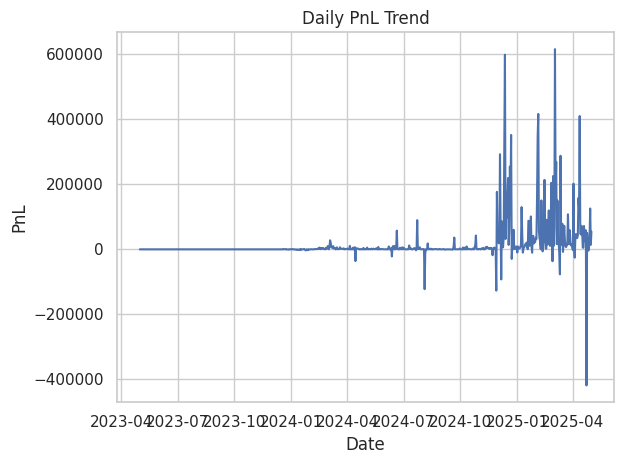

In [66]:
# ==============================
# TIME SERIES ANALYSIS
# ==============================

daily_pnl = merged_df.groupby('date')['closed_pnl'].sum()

plt.figure()
daily_pnl.plot()
plt.title("Daily PnL Trend")
plt.xlabel("Date")
plt.ylabel("PnL")
plt.tight_layout()
plt.show()

10. CORRELATION ANALYSIS

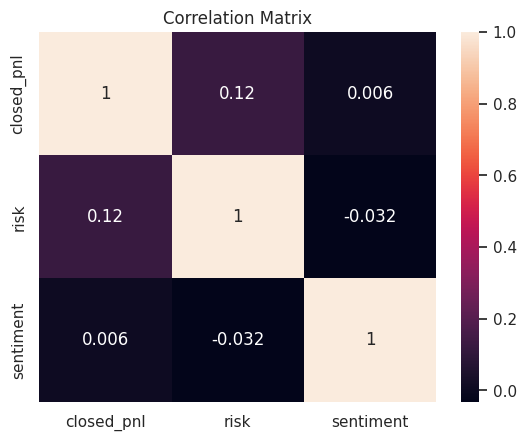

In [67]:
# ==============================
# CORRELATION ANALYSIS
# ==============================

corr = merged_df[['closed_pnl', 'risk', 'sentiment']].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

11. FINAL INSIGHTS

In [68]:
# ==============================
# STRATEGIC INSIGHTS (FINAL)
# ==============================

print("\n=== STRATEGIC INSIGHTS ===")

print("1. Trading during Greed phases may yield higher profitability but involves higher risk exposure.")
print("2. Conservative strategies may perform better during Fear periods due to lower volatility.")
print("3. Monitoring market sentiment can improve timing of entry and exit decisions.")
print("4. Top traders show less dependency on sentiment, indicating strong strategy or discipline.")
print("5. Combining sentiment signals with risk management can enhance trading performance.")


=== STRATEGIC INSIGHTS ===
1. Trading during Greed phases may yield higher profitability but involves higher risk exposure.
2. Conservative strategies may perform better during Fear periods due to lower volatility.
3. Monitoring market sentiment can improve timing of entry and exit decisions.
4. Top traders show less dependency on sentiment, indicating strong strategy or discipline.
5. Combining sentiment signals with risk management can enhance trading performance.
